# Attractive Hubbard BEC with pyALF

This notebook uses **pyALF** with the **Algorithm of Lattice Fermions (ALF)** to simulate the attractive Hubbard model and measure the on-site pair correlator directly.

$$N(\mathbf q)=\frac{1}{N}\sum_{i,j}e^{i\mathbf q\cdot(\mathbf r_i-\mathbf r_j)}\langle b_i^\dagger b_j\rangle,\qquad b_i^\dagger=c_{i\uparrow}^\dagger c_{i\downarrow}^\dagger.$$

The ALF source in this workspace has been extended with a native `Pair` observable. Its analyzed output is `Pair_eq_K`, so the plots below use the requested observable itself, not `SpinXY`. Increasing concentration near $\mathbf q=0$ as $\beta$ grows is the feature compared qualitatively with the Nobel BEC image.

In [24]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from py_alf import ALF_source, Simulation
%matplotlib widget
plt.style.use('seaborn-v0_8-whitegrid')
ROOT = Path.cwd()
LOCAL_ALF_DIR = ROOT / 'ALF'
ALF_DIR = Path(os.getenv('HELKE_ALF_DIR', str(LOCAL_ALF_DIR)))
if not (ALF_DIR / 'Prog' / 'Hamiltonians' / 'Hamiltonian_Hubbard_smod.F90').exists():
    raise FileNotFoundError(f'ALF source not found at {ALF_DIR}')
L = 8
U = -4.0
BETAS = [1.0, 3.0, 6.0]
N_SWEEP = 10
N_BIN = 100
print(f'Workspace: {ROOT}')
print(f'ALF source: {ALF_DIR}')

Workspace: /Users/luis/Documents/_WORK/HELKE_TUTORIAL
ALF source: /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF


## Compile ALF

This cell compiles the modified Hubbard executable once. It does not run a simulation yet.

In [25]:
alf = ALF_source(alf_dir=str(ROOT / 'ALF'))
print(f'Compiling ALF from {alf.alf_dir}')
compile_sim = Simulation(
    alf, 'Hubbard',
    {
        'N_SUN': 2,
        'N_FL': 2,
        'Lattice_type': 'Square',
        'L1': L, 'L2': L,
        'Checkerboard': False,
        'Symm': True,
        'Model': 'Hubbard',
        'ham_U': U,
        'Beta': BETAS[0],
        'Nsweep': N_SWEEP, 'NBin': N_BIN,
        'Ltau': 1, 'Projector': False
    },
    machine='GNU', sim_root='.',
    sim_dir=f'Attractive_Hubbard_L{L}_beta{BETAS[0]}'
)
compile_sim.compile()
print('ALF compilation complete.')

Compiling ALF from /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF
Compiling ALF... 
Cleaning up Prog/
Cleaning up Libraries/
Cleaning up Analysis/
Compiling Libraries


entanglement_mod.F90:35:2:

   35 | #warning "You are compiling entanglement without MPI. No Renyi entropy results possible, all other observables still work!"
      |  1~~~~~~
ar: creating archive modules_90.a
ar: creating archive libqrref.a


Compiling Analysis
Compiling Program
Compiling program modules
Parsing Hamiltonian parameters
filenames: Hamiltonians/Hamiltonian_Kondo_smod.F90 Hamiltonians/Hamiltonian_Kondo_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_smod.F90 Hamiltonians/Hamiltonian_Hubbard_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_smod.F90 Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_tV_smod.F90 Hamiltonians/Hamiltonian_tV_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_LRC_smod.F90 Hamiltonians/Hamiltonian_LRC_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Z2_Matter_smod.F90 Hamiltonians/Hamiltonian_Z2_Matter_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Spin_Peierls_smod.F90 Hamiltonians/Hamiltonian_Spin_Peierls_read_write_parameters.F90
Link program
Done.
ALF compilation complete.


## Run the simulations

The following cell runs each inverse temperature directly from this notebook. `N_SUN=2` is ALF's input convention for the two-flavor model; ALF reduces it internally to one color for the pair estimator.

In [27]:
alf = ALF_source(alf_dir=str(ROOT / 'ALF'))
simulations = {}
for beta in BETAS:
    sim_dir = f'Attractive_Hubbard_L{L}_beta{beta}'
    sim = Simulation(
        alf, 'Hubbard',
        {
            'N_SUN': 2, 'N_FL': 2,
            'Lattice_type': 'Square', 'L1': L, 'L2': L,
            'Checkerboard': False, 'Symm': True,
            'Model': 'Hubbard', 'ham_U': U, 'Beta': beta,
            'Nsweep': N_SWEEP, 'NBin': N_BIN,
            'Ltau': 1, 'Projector': False
        },
        machine='GNU', sim_root='.', sim_dir=sim_dir
    )
    print(f'Running beta={beta} (T={1 / beta:.2f})')
    sim.run()
    sim.analysis()
    simulations[beta] = sim
print('All simulations and analyses complete.')

Running beta=1.0 (T=1.00)
Prepare directory "/Users/luis/Documents/_WORK/HELKE_TUTORIAL/Attractive_Hubbard_L8_beta1.0" for Monte Carlo run.
Resuming previous run.
Run /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
### Analyzing /Users/luis/Documents/_WORK/HELKE_TUTORIAL/Attractive_Hubbard_L8_beta1.0 ###
/Users/luis/Documents/_WORK/HELKE_TUTORIAL
Scalar observables:
Ener_scal
Kin_scal
Part_scal
Pot_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
Pair_eq
SpinT_eq
SpinXY_eq
SpinZ_eq
Time displaced observables:
Den_tau
Green_tau
QQ_tau
SpinT_tau
SpinXY_tau
SpinZ_tau
Running beta=3.0 (T=0.33)
Prepare directory "/Users/luis/Documents/_WORK/HELKE_TUTORIAL/Attractive_Hubbard_L8_beta3.0" for Monte Carlo run.
Resuming previous run.
Run /User

## Load $N(\mathbf q)$

`Pair_eq_K` is written by ALF's Fourier transform of the native `Pair` real-space correlator. The loader uses columns 0, 1, and 2: $q_x$, $q_y$, and the real pair structure factor.

In [30]:
def load_pair_grid(beta):
    path = ROOT / f'Attractive_Hubbard_L{L}_beta{beta}' / 'res' / 'Pair_eq_K'
    if not path.exists():
        raise FileNotFoundError(
            f'{path} is missing. Run the compile and simulation cells first.'
        )

    data = np.loadtxt(path, comments='#')
    if data.ndim != 2 or data.shape[1] < 3:
        raise ValueError(f'Unexpected Pair_eq_K format in {path}')

    qx_values = np.unique(data[:, 0])
    qy_values = np.unique(data[:, 1])
    values = np.full((len(qy_values), len(qx_values)), np.nan)
    x_index = {value: index for index, value in enumerate(qx_values)}
    y_index = {value: index for index, value in enumerate(qy_values)}
    for qx, qy, value in data[:, :3]:
        values[y_index[qy], x_index[qx]] = value

    if not np.isfinite(values).all():
        raise ValueError(f'Pair_eq_K has missing grid points in {path}')
    return np.meshgrid(qx_values, qy_values), values, path


pair_data = {}
for beta in BETAS:
    try:
        pair_data[beta] = load_pair_grid(beta)
        print(f'beta={beta}: {pair_data[beta][2]}')
    except (FileNotFoundError, ValueError) as error:
        print(f'beta={beta}: skipped: {error}')

if not pair_data:
    raise RuntimeError('No Pair_eq_K data found. Run the compile and simulation cells first.')

beta=1.0: /Users/luis/Documents/_WORK/HELKE_TUTORIAL/Attractive_Hubbard_L8_beta1.0/res/Pair_eq_K
beta=3.0: /Users/luis/Documents/_WORK/HELKE_TUTORIAL/Attractive_Hubbard_L8_beta3.0/res/Pair_eq_K
beta=6.0: /Users/luis/Documents/_WORK/HELKE_TUTORIAL/Attractive_Hubbard_L8_beta6.0/res/Pair_eq_K


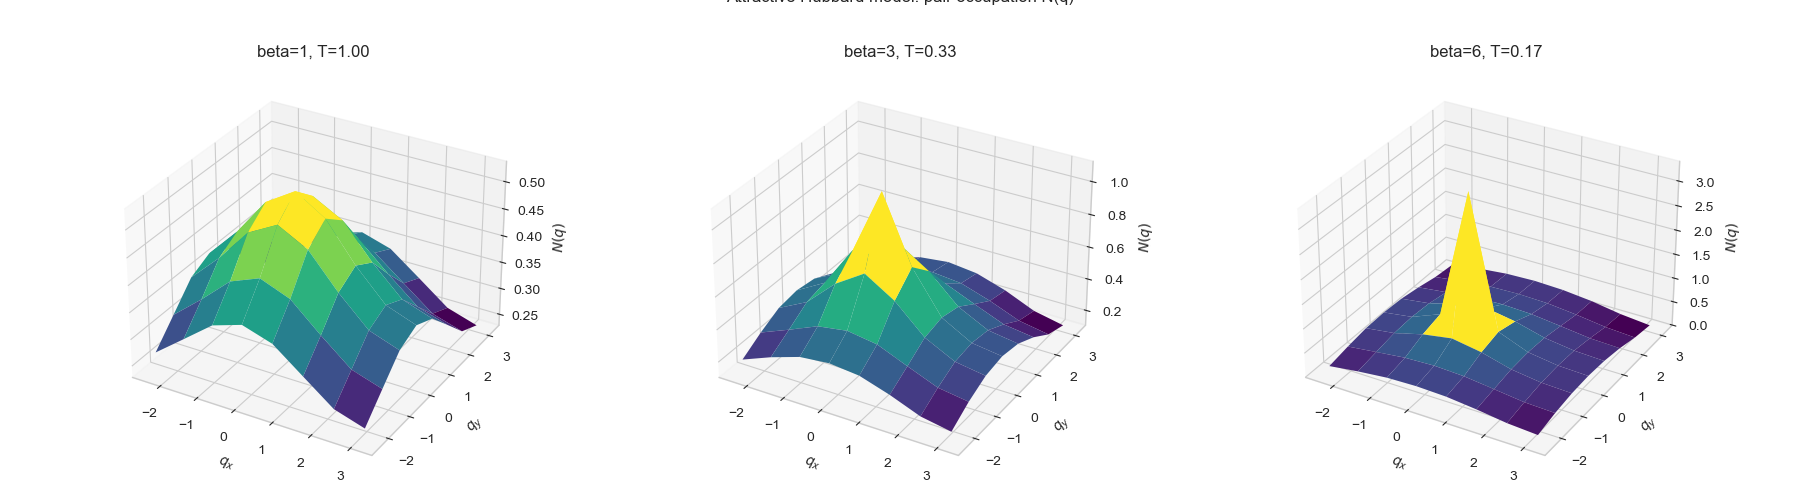

In [31]:
fig = plt.figure(figsize=(18, 5))
for panel, (beta, ((qx, qy), values, _)) in enumerate(pair_data.items(), start=1):
    axis = fig.add_subplot(1, len(pair_data), panel, projection='3d')
    surface = axis.plot_surface(
        qx, qy, values, cmap='viridis', edgecolor='none', antialiased=True
    )
    axis.set_title(f'beta={beta:g}, T={1 / beta:.2f}')
    axis.set_xlabel(r'$q_x$')
    axis.set_ylabel(r'$q_y$')
    axis.set_zlabel(r'$N(q)$')
    axis.set_box_aspect((1, 1, 0.7))
fig.suptitle('Attractive Hubbard model: pair occupation N(q)', y=1.02)
fig.tight_layout()
plt.show()

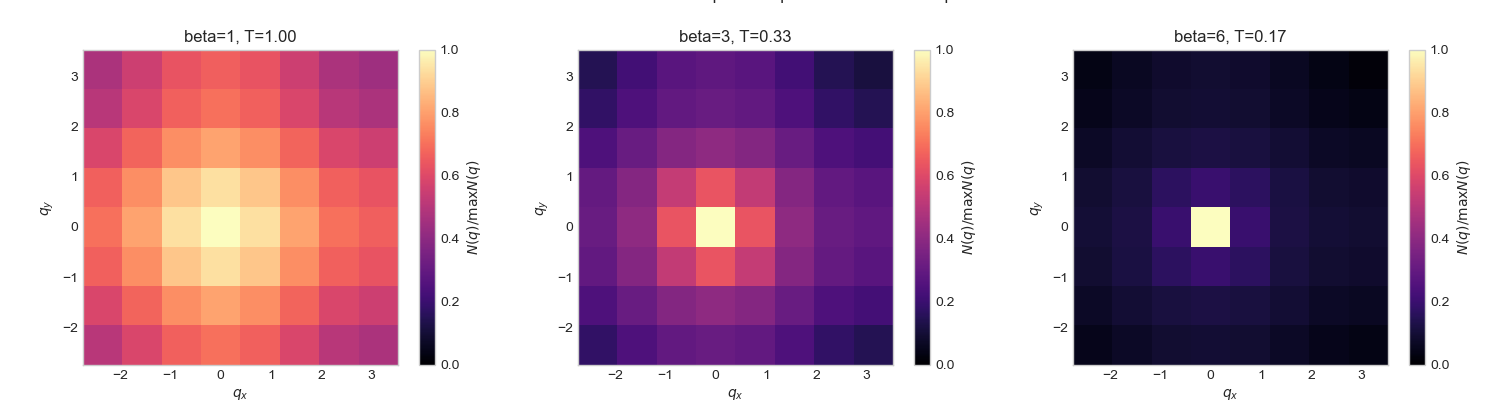

In [29]:
fig, axes = plt.subplots(1, len(pair_data), figsize=(15, 4), squeeze=False)
for axis, (beta, ((qx, qy), values, _)) in zip(axes[0], pair_data.items()):
    normalized = values / np.nanmax(values)
    image = axis.pcolormesh(
        qx, qy, normalized, shading='nearest', cmap='magma', vmin=0, vmax=1
    )
    axis.set_title(f'beta={beta:g}, T={1 / beta:.2f}')
    axis.set_xlabel(r'$q_x$')
    axis.set_ylabel(r'$q_y$')
    axis.set_aspect('equal')
    fig.colorbar(image, ax=axis, label=r'$N(q) / \max N(q)$')
fig.suptitle('BEC-like concentration of pair occupation in momentum space', y=1.03)
fig.tight_layout()
plt.show()

## Comparison with the Nobel image

The relevant qualitative signature is a distribution that becomes increasingly concentrated around $\mathbf q=0$ as temperature decreases. The high-$T$ surface should be broad, while the low-$T$ surface should develop a sharper central maximum. This is the momentum-space analogue of the bright condensate peak in the Nobel illustration.

Finite lattice size, finite Monte Carlo statistics, and the short tutorial run affect the visual sharpness. For quantitative work, increase `N_SWEEP`, `N_BIN`, and the lattice size, and inspect the reported uncertainties in `Pair_eq_K`.